Import Libraries

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

In [ ]:
!unzip 'FruitinAmazon.zip'

Archive:  FruitinAmazon.zip
  inflating: FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: FruitinAmazon/test/acai/images (2).jpeg  
  inflating: FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: FruitinAmazon/test/acai/images (16).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: FruitinAmazon/train/acai/images (3).jpeg  
  inflating: FruitinAmazon/train/acai/images (4).jpeg  
  inflating: FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (4).jpeg  
  inflating: FruitinAmazon/train/acai/images (11).jpeg  
  inflating: FruitinAmazon/test/tucuma/download (1).jpeg  
  inflating: FruitinAmazon/test/acai/images.jpeg  
  inflating: FruitinAmazon/train/acai/ima

Set Dataset Path

In [ ]:
train_dir = "/content/FruitinAmazon/train"
test_dir = "/content/FruitinAmazon/test"

TASK 1:Data Understanding & Visualization

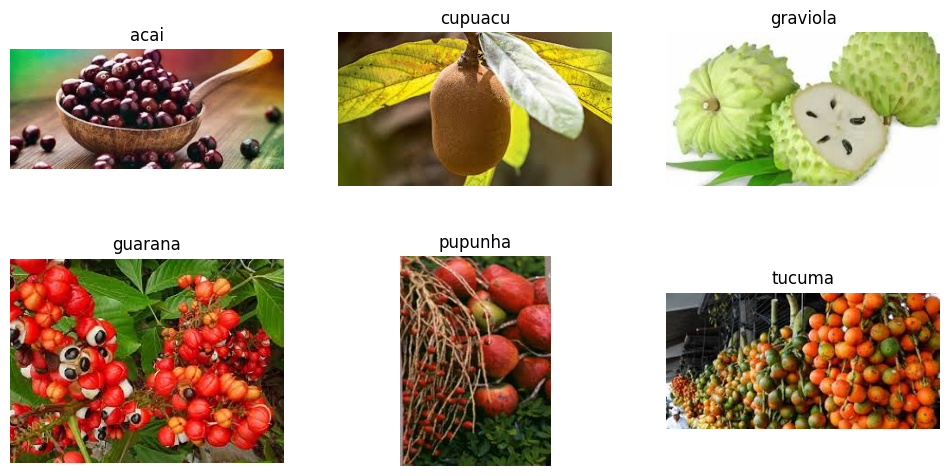

In [ ]:
class_names = sorted(os.listdir(train_dir))

plt.figure(figsize=(12,6))

for i, class_name in enumerate(class_names[:6]):
    class_path = os.path.join(train_dir, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.show()

Observation

In [ ]:
observation = """
The dataset contains multiple fruit classes stored in separate directories.
Images vary in color, size, and background.
Each class has distinct visual features, making it suitable for classification using CNN.
"""
print(observation)


The dataset contains multiple fruit classes stored in separate directories.
Images vary in color, size, and background.
Each class has distinct visual features, making it suitable for classification using CNN.



TASK 1 (Part 2): Check Corrupted Images

In [ ]:
corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except:
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


TASK 2: Load Dataset (Keras)

In [ ]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

Training Dataset

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 72 files for training.


Validation Dataset

In [ ]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

Found 90 files belonging to 6 classes.
Using 18 files for validation.


Normalization

In [ ]:
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

TASK 3: CNN Model

In [ ]:
num_classes = len(class_names)

model = tf.keras.Sequential([

    # Conv Layer 1
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Conv Layer 2
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),

    # Output
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

TASK 4: Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

TASK 4: Training

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_loss', save_best_only=True)

early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.1655 - loss: 1.8698

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 555ms/step - accuracy: 0.1528 - loss: 1.9059 - val_accuracy: 0.0000e+00 - val_loss: 2.2656
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.3108 - loss: 1.7215

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.2917 - loss: 1.7334 - val_accuracy: 0.8333 - val_loss: 1.3571
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 419ms/step - accuracy: 0.3611 - loss: 1.6547 - val_accuracy: 0.7778 - val_loss: 1.4484
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.4740 - loss: 1.5062

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 442ms/step - accuracy: 0.5000 - loss: 1.4675 - val_accuracy: 0.6111 - val_loss: 1.3249
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step - accuracy: 0.5341 - loss: 1.2307

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 450ms/step - accuracy: 0.5556 - loss: 1.2077 - val_accuracy: 0.7222 - val_loss: 0.8769
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 406ms/step - accuracy: 0.6528 - loss: 1.0211 - val_accuracy: 0.6111 - val_loss: 1.0973
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 667ms/step - accuracy: 0.7083 - loss: 0.8623 - val_accuracy: 0.5556 - val_loss: 1.1793
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 0.7112 - loss: 0.7363

...

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 442ms/step - accuracy: 0.8889 - loss: 0.4738 - val_accuracy: 0.7222 - val_loss: 0.6421
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 0.9028 - loss: 0.3311 - val_accuracy: 0.6111 - val_loss: 0.8445
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step - accuracy: 0.9028 - loss: 0.3531 - val_accuracy: 0.8333 - val_loss: 0.6773
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step - accuracy: 0.9861 - loss: 0.1973 - val_accuracy: 0.8333 - val_loss: 0.7805
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 331ms/step - accuracy: 0.9705 - loss: 0.1901

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 443ms/step - accuracy: 0.9583 - loss: 0.1898 - val_accuracy: 0.8333 - val_loss: 0.6274
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9902 - loss: 0.1041

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 439ms/step - accuracy: 0.9861 - loss: 0.1062 - val_accuracy: 0.8333 - val_loss: 0.4082
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 1.0000 - loss: 0.0573

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 805ms/step - accuracy: 1.0000 - loss: 0.0578 - val_accuracy: 0.8889 - val_loss: 0.3136
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 1.0000 - loss: 0.0575

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 537ms/step - accuracy: 1.0000 - loss: 0.0519 - val_accuracy: 0.8889 - val_loss: 0.2853
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 413ms/step - accuracy: 1.0000 - loss: 0.0357 - val_accuracy: 0.8889 - val_loss: 0.3475
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 402ms/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy: 0.8889 - val_loss: 0.4708
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 418ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 0.8333 - val_loss: 0.5173
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 408ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 0.8333 - val_loss: 0.4693
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 407ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.8333 - val_loss: 0.3982


TASK 5: Evaluation

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6000 - loss: 1.3274
Test Accuracy: 0.6000000238418579


TASK 6: Save & Load Model

In [ ]:
model.save("cnn_model.h5")

In [ ]:
loaded_model = tf.keras.models.load_model("cnn_model.h5")

loss, acc = loaded_model.evaluate(test_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 762ms/step - accuracy: 0.6000 - loss: 1.3274
Loaded Model Accuracy: 0.6000000238418579


TASK 7: Predictions + Classification Report

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.56      1.00      0.71         5
     guarana       1.00      0.40      0.57         5
     pupunha       0.67      0.40      0.50         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.60        30
   macro avg       0.64      0.60      0.57        30
weighted avg       0.64      0.60      0.57        30



GRAPH

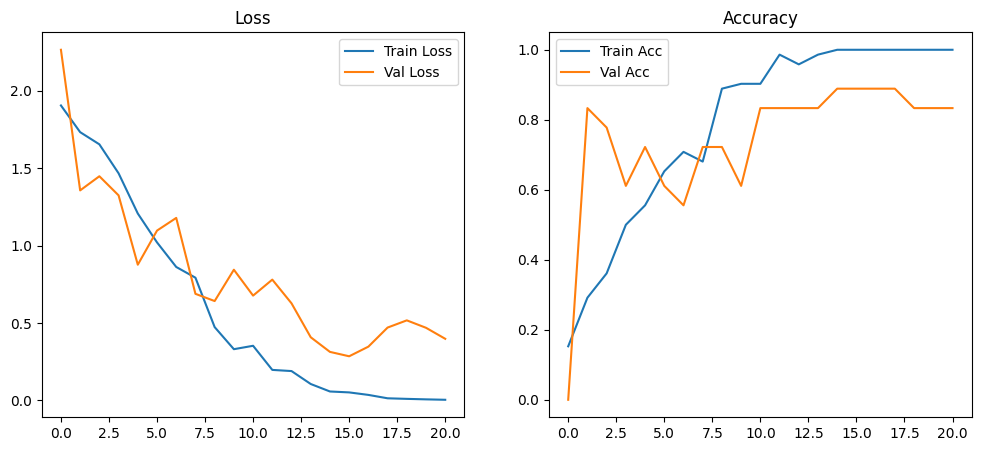

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy")

plt.show()